# Cognifyz Data Science Internship
## Level 3 - Task 1: Predictive Modeling

### Objective

Build regression models to predict the Aggregate Rating of restaurants.

### Tasks

- Prepare the dataset for predictive modeling.
- Select relevant features.
- Split the data into training and testing sets.
- Train regression models.
- Evaluate model performance.
- Compare different regression algorithms.

### import libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

### Load the dataset

In [43]:
df=pd.read_csv("Cleaned_Dataset.csv")
print('Dataset Shape:', df.shape)

Dataset Shape: (9551, 21)


In [44]:
print("Available columns:")
for i, col in enumerate(df.columns, start=1):
    print(i, repr(col))

Available columns:
1 'Restaurant ID'
2 'Restaurant Name'
3 'Country Code'
4 'City'
5 'Address'
6 'Locality'
7 'Locality Verbose'
8 'Longitude'
9 'Latitude'
10 'Cuisines'
11 'Average Cost for two'
12 'Currency'
13 'Has Table booking'
14 'Has Online delivery'
15 'Is delivering now'
16 'Switch to order menu'
17 'Price range'
18 'Aggregate rating'
19 'Rating color'
20 'Rating text'
21 'Votes'


### Check the target variable

In [45]:
print("Aggregate Rating information:")
print(df["Aggregate rating"].describe())

print("\nMissing values:")
print(df["Aggregate rating"].isnull().sum())

Aggregate Rating information:
count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

Missing values:
0


In [46]:
# Create engineered features

df["Restaurant Name Length"] = df["Restaurant Name"].str.len()

df["Address Length"] = df["Address"].str.len()

df["Has Table Booking Encoded"] = (
    df["Has Table booking"].map({"Yes": 1, "No": 0})
)

df["Has Online Delivery Encoded"] = (
    df["Has Online delivery"].map({"Yes": 1, "No": 0})
)

print("Feature engineering completed successfully!")

display(
    df[
        [
            "Restaurant Name",
            "Restaurant Name Length",
            "Address Length",
            "Has Table booking",
            "Has Table Booking Encoded",
            "Has Online delivery",
            "Has Online Delivery Encoded"
        ]
    ].head(10)
)

Feature engineering completed successfully!


,Restaurant Name,Restaurant Name Length,Address Length,Has Table booking,Has Table Booking Encoded,Has Online delivery,Has Online Delivery Encoded
0,Le Petit Souffle,16,71,Yes,1,No,0
1,Izakaya Kikufuji,16,67,Yes,1,No,0
2,Heat - Edsa Shangri-La,22,56,Yes,1,No,0
3,Ooma,4,70,No,0,No,0
4,Sambo Kojin,11,64,Yes,1,No,0
5,Din Tai Fung,12,71,No,0,No,0
6,Buffet 101,10,83,Yes,1,No,0
7,Vikings,7,81,Yes,1,No,0
8,Spiral - Sofitel Philippine Plaza Manila,40,69,Yes,1,No,0
9,Locavore,8,67,Yes,1,No,0


In [47]:
features = [
    "Price range",
    "Votes",
    "Has Table Booking Encoded",
    "Has Online Delivery Encoded",
    "Restaurant Name Length",
    "Address Length"
]

X = df[features]
y = df["Aggregate rating"]

print("Selected features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Selected features:
['Price range', 'Votes', 'Has Table Booking Encoded', 'Has Online Delivery Encoded', 'Restaurant Name Length', 'Address Length']

X shape: (9551, 6)
y shape: (9551,)


### check for missing values

In [48]:
print("Missing values in selected features:")
display(X.isnull().sum().to_frame("Missing Values"))

print("\nTarget missing values:")
print(y.isnull().sum())

Missing values in selected features:


,Missing Values
Price range,0
Votes,0
Has Table Booking Encoded,0
Has Online Delivery Encoded,0
Restaurant Name Length,0
Address Length,0



Target missing values:
0


### Split the dataset

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 7640
Testing samples: 1911


### Train Linear Regression

In [50]:

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.66, 0. ,-0.23, 0.64,-0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Price range','Votes','Has Table Booking Encoded', 'Has Online Delivery Encoded','Restaurant Name Length','Address Length']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.414
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [51]:
y_pred = linear_model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[1.87491249 3.2253446  2.5397552  2.69420053 1.92058704 1.92722365
 2.54140235 1.88314535 2.59093798 3.22179489]


### Evaluate Linear Regression

In [52]:
mae_linear = mean_absolute_error(y_test, y_pred)
mse_linear = mean_squared_error(y_test, y_pred)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Performance
--------------------------------
MAE : 1.0756607794423119
MSE : 1.6778651605750712
RMSE: 1.2953243457046082
R²  : 0.26283619645694956


### Compare actual vs predicted ratings

In [55]:
comparison = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": y_pred
})

display(comparison.head(10))

,Actual Rating,Predicted Rating
0,2.1,1.874912
1,4.1,3.225345
2,3.2,2.539755
3,4.4,2.694201
4,3.5,1.920587
5,0.0,1.927224
6,3.2,2.541402
7,0.0,1.883145
8,3.6,2.590938
9,4.0,3.221795


### Train Decision Tree Regression

In [62]:
decision_tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

decision_tree_model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with `

In [63]:
y_pred_tree = decision_tree_model.predict(X_test)

print(y_pred_tree[:10])

[3.40943396 3.15952381 3.16445242 3.44444444 3.04597701 0.
 3.16445242 0.         3.19752066 3.16445242]


In [64]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regression Performance")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

Decision Tree Regression Performance
MAE : 0.23662058865478555
MSE : 0.13196296717939618
RMSE: 0.36326707417463006
R²  : 0.9420225623020569


### Train Random Forest Regression

In [61]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [66]:
y_pred_forest = random_forest_model.predict(X_test)

print(y_pred_forest[:10])

[3.23734007 3.19733744 3.19776803 3.39462753 3.07431515 0.
 3.15278757 0.         3.23929433 3.10379857]


In [68]:
mae_forest = mean_absolute_error(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print("Random Forest Regression Performance")
print("MAE :", mae_forest)
print("MSE :", mse_forest)
print("RMSE:", rmse_forest)
print("R²  :", r2_forest)

Random Forest Regression Performance
MAE : 0.2226065157136901
MSE : 0.11554340225748362
RMSE: 0.339916757835626
R²  : 0.9492364369415486


### Model comparison

In [69]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_forest
    ],
    "MSE": [
        mse_linear,
        mse_tree,
        mse_forest
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_forest
    ],
    "R²": [
        r2_linear,
        r2_tree,
        r2_forest
    ]
})

display(model_comparison.round(4))

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,1.0757,1.6779,1.2953,0.2628
1,Decision Tree,0.2366,0.1320,0.3633,0.9420
2,Random Forest,0.2226,0.1155,0.3399,0.9492


### Visualize R² scores

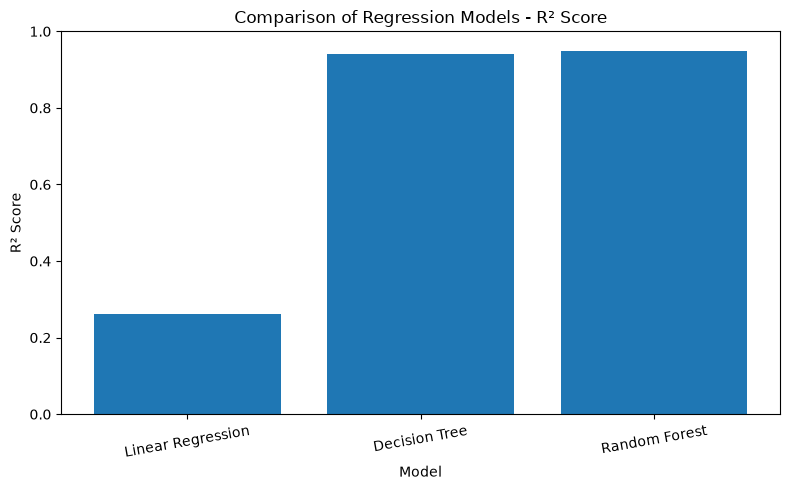

In [71]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["R²"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Comparison of Regression Models - R² Score")
plt.ylim(0, 1)

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### Visualize RMSE

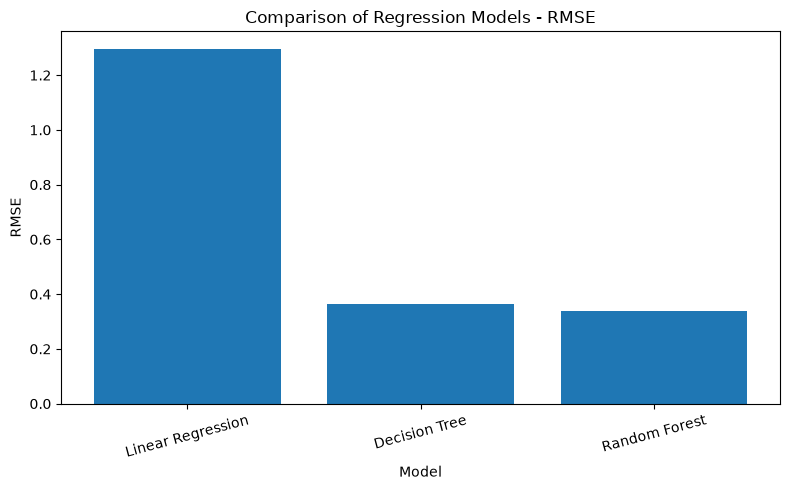

In [72]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Comparison of Regression Models - RMSE")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [73]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,Votes,0.979799
5,Address Length,0.006453
4,Restaurant Name Length,0.004734
0,Price range,0.004058
3,Has Online Delivery Encoded,0.003120
2,Has Table Booking Encoded,0.001837


### Feature importance

In [74]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,Votes,0.979799
5,Address Length,0.006453
4,Restaurant Name Length,0.004734
0,Price range,0.004058
3,Has Online Delivery Encoded,0.003120
2,Has Table Booking Encoded,0.001837


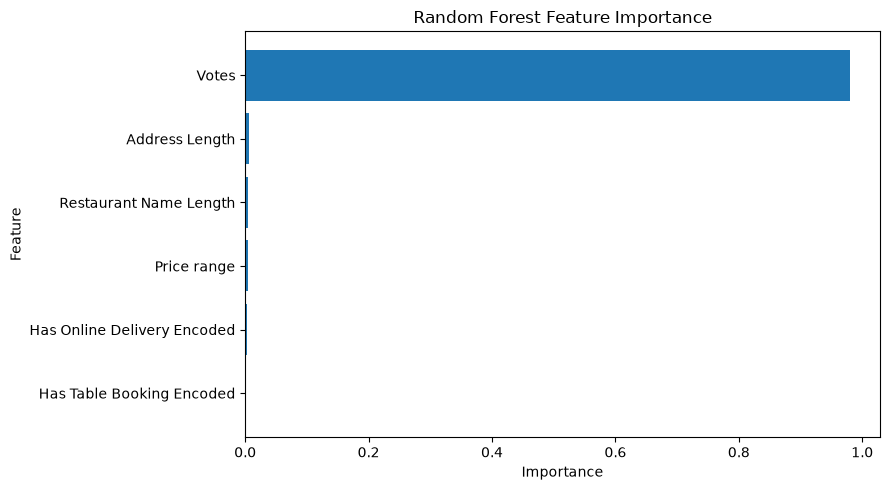

In [75]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Actual vs Predicted Ratings

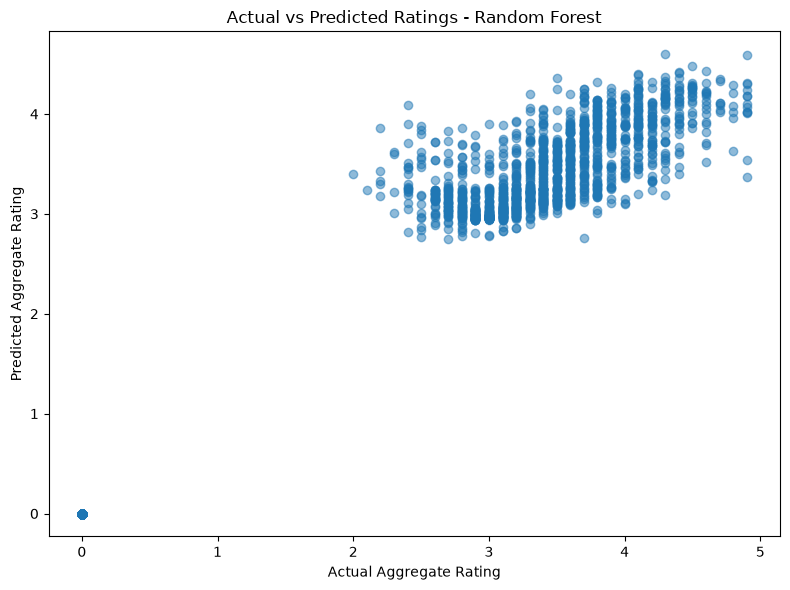

In [76]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_forest,
    alpha=0.5
)

plt.xlabel("Actual Aggregate Rating")
plt.ylabel("Predicted Aggregate Rating")
plt.title("Actual vs Predicted Ratings - Random Forest")

plt.tight_layout()
plt.show()

### prediction error column

In [77]:
prediction_results = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": y_pred_forest
})

prediction_results["Absolute Error"] = (
    abs(
        prediction_results["Actual Rating"]
        - prediction_results["Predicted Rating"]
    )
)

display(prediction_results.head(10))

,Actual Rating,Predicted Rating,Absolute Error
0,2.1,3.237340,1.137340
1,4.1,3.197337,0.902663
2,3.2,3.197768,0.002232
3,4.4,3.394628,1.005372
4,3.5,3.074315,0.425685
5,0.0,0.000000,0.000000
6,3.2,3.152788,0.047212
7,0.0,0.000000,0.000000
8,3.6,3.239294,0.360706
9,4.0,3.103799,0.896201


### Final model summary

In [78]:
best_model_results = model_comparison.sort_values(
    by="R²",
    ascending=False
)

display(best_model_results.round(4))

,Model,MAE,MSE,RMSE,R²
2,Random Forest,0.2226,0.1155,0.3399,0.9492
1,Decision Tree,0.2366,0.1320,0.3633,0.9420
0,Linear Regression,1.0757,1.6779,1.2953,0.2628


## Conclusion

Three regression algorithms were evaluated for predicting restaurant Aggregate Rating:

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression

Linear Regression provided a baseline performance with an R² score of approximately 0.263.

The Decision Tree model achieved an R² score of approximately 0.942.

The Random Forest model achieved an R² score of approximately 0.949, with an RMSE of approximately 0.340.

The model comparison demonstrates that the tree-based models captured relationships in the selected features more effectively than the linear baseline on this test split.

Feature importance from the Random Forest model was also analyzed to understand the relative contribution of the input features.

These results describe predictive performance on the selected dataset and test split; they do not establish causal relationships between the features and restaurant ratings.

In [80]:
print(feature_importance)

                       Feature  Importance
1                        Votes    0.979799
5               Address Length    0.006453
4       Restaurant Name Length    0.004734
0                  Price range    0.004058
3  Has Online Delivery Encoded    0.003120
2    Has Table Booking Encoded    0.001837
